# Limpieza de datos Proyecto 1

Analitica Computacional para la toma de decisiones

Departamento de Ingeniería Industrial

Universidad de los Andes



**Integrantes:** Sofia Vasquez, Isabella Caputi, Maria Paula Ospina

# Carga de datos

In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv("Datos_Atlantico.csv", sep=",")

Se cargó el conjunto de datos utilizando pandas y se realizó una inspección inicial de la estructura del conjunto de datos.

In [3]:
df.columns = (
    df.columns
    .str.lower()
    .str.strip()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

df.columns.tolist()[:20]


['periodo',
 'estu_tipodocumento',
 'estu_consecutivo',
 'cole_area_ubicacion',
 'cole_bilingue',
 'cole_calendario',
 'cole_caracter',
 'cole_cod_dane_establecimiento',
 'cole_cod_dane_sede',
 'cole_cod_depto_ubicacion',
 'cole_cod_mcpio_ubicacion',
 'cole_codigo_icfes',
 'cole_depto_ubicacion',
 'cole_genero',
 'cole_jornada',
 'cole_mcpio_ubicacion',
 'cole_naturaleza',
 'cole_nombre_establecimiento',
 'cole_nombre_sede',
 'cole_sede_principal']

In [4]:
df.head()

,periodo,estu_tipodocumento,estu_consecutivo,cole_area_ubicacion,cole_bilingue,cole_calendario,cole_caracter,cole_cod_dane_establecimiento,cole_cod_dane_sede,cole_cod_depto_ubicacion,...,fami_tienecomputador,fami_tieneinternet,fami_tienelavadora,desemp_ingles,punt_ingles,punt_matematicas,punt_sociales_ciudadanas,punt_c_naturales,punt_lectura_critica,punt_global
0,20132,TI,SB11201320110716,URBANO,N,A,TÉCNICO/ACADÉMICO,1.080010e+11,108001001961,8,...,Si,No,Si,A-,40.0,46.0,NaN,NaN,NaN,NaN
1,20122,TI,SB11201220568962,URBANO,N,A,ACADÉMICO,3.084330e+11,308433001171,8,...,Si,No,Si,A-,36.0,38.0,NaN,NaN,NaN,NaN
2,20122,TI,SB11201220266323,URBANO,NaN,A,TÉCNICO/ACADÉMICO,1.080010e+11,108001005567,8,...,Si,Si,Si,A-,43.0,38.0,NaN,NaN,NaN,NaN
3,20112,CC,SB11201120274685,URBANO,N,A,NO APLICA,3.080010e+11,308001015979,8,...,No,No,No,A1,43.0,35.0,NaN,NaN,NaN,NaN
4,20121,CC,SB11201210053765,URBANO,N,A,ACADÉMICO,3.080010e+11,308001001633,8,...,Si,Si,Si,A-,43.0,30.0,NaN,NaN,NaN,NaN


Como se observa, cada registro representa un estudiante e incluye variables demográficas, socioeconómicas, características del establecimiento educativo y resultados académicos. Las variables demográficas incluyen el género del estudiante (estu_genero) y el municipio de ubicación del colegio (cole_mcpio_ubicacion). Entre las variables socioeconómicas estan: el estrato de la vivienda (fami_estratovivienda), el nivel educativo de la madre y del padre,  el acceso a internet y computador en el hogar.

En cuanto al contexto educativo, se incluyen características del colegio como el área de ubicación (urbano), naturaleza (oficial) y jornada académica. Finalmente, se presentan los puntajes obtenidos en las distintas áreas evaluadas (Matemáticas, Lectura Crítica, Ciencias Naturales, Sociales e Inglés), y el puntaje global (el total de todas las areas).

# Manejo Datos faltantes

 Se revisaron los tipos de datos y la cantidad de valores nulos por variable con el fin de evaluar la calidad de los datos antes de iniciar el proceso de limpieza.

In [5]:
df.isna()

,periodo,estu_tipodocumento,estu_consecutivo,cole_area_ubicacion,cole_bilingue,cole_calendario,cole_caracter,cole_cod_dane_establecimiento,cole_cod_dane_sede,cole_cod_depto_ubicacion,...,fami_tienecomputador,fami_tieneinternet,fami_tienelavadora,desemp_ingles,punt_ingles,punt_matematicas,punt_sociales_ciudadanas,punt_c_naturales,punt_lectura_critica,punt_global
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,True,True,True
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,True,True,True
2,False,False,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,True,True,True,True
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,True,True,True
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
389443,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
389444,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
389445,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
389446,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [6]:
df.isna().sum(axis=0)

periodo                               0
estu_tipodocumento                    0
estu_consecutivo                      0
cole_area_ubicacion                 187
cole_bilingue                     54049
cole_calendario                       9
cole_caracter                      8261
cole_cod_dane_establecimiento       123
cole_cod_dane_sede                    0
cole_cod_depto_ubicacion              0
cole_cod_mcpio_ubicacion              0
cole_codigo_icfes                   602
cole_depto_ubicacion                  0
cole_genero                           0
cole_jornada                          0
cole_mcpio_ubicacion                  0
cole_naturaleza                       0
cole_nombre_establecimiento           0
cole_nombre_sede                      0
cole_sede_principal                   0
estu_cod_depto_presentacion           0
estu_cod_mcpio_presentacion           0
estu_cod_reside_depto                 0
estu_cod_reside_mcpio                 0
estu_depto_presentacion               0


In [7]:
df.shape

(389448, 51)

Durante el análisis de calidad de datos se identificó que algunas variables presentaban valores faltantes. El caso más relevante corresponde a las variables de puntaje (punt_global, punt_lectura_critica, punt_c_naturales y punt_sociales_ciudadanas), que presentaban aproximadamente un **35% de valores nulos.**

In [8]:
df.isna().sum()/df.shape[0]*100

periodo                           0.000000
estu_tipodocumento                0.000000
estu_consecutivo                  0.000000
cole_area_ubicacion               0.048017
cole_bilingue                    13.878361
cole_calendario                   0.002311
cole_caracter                     2.121207
cole_cod_dane_establecimiento     0.031583
cole_cod_dane_sede                0.000000
cole_cod_depto_ubicacion          0.000000
cole_cod_mcpio_ubicacion          0.000000
cole_codigo_icfes                 0.154578
cole_depto_ubicacion              0.000000
cole_genero                       0.000000
cole_jornada                      0.000000
cole_mcpio_ubicacion              0.000000
cole_naturaleza                   0.000000
cole_nombre_establecimiento       0.000000
cole_nombre_sede                  0.000000
cole_sede_principal               0.000000
estu_cod_depto_presentacion       0.000000
estu_cod_mcpio_presentacion       0.000000
estu_cod_reside_depto             0.000000
estu_cod_re

Aunque el porcentaje de valores faltantes para el puntaje globbal es alto (35.29%), se decidió eliminar estos registros porque:

*   El puntaje global es la variable principal de análisis de negocio
*   Los registros sin puntaje no permiten evaluar desempeño académico
*   Mantenerlos introduciría sesgos en cálculos de promedio y comparaciones
*   No es metodológicamente ni eticamente correcto imputar puntajes académicos con valores artificiales
* Si fueramos a sumar los resultados de ingles y matematicas (los unicos completos), el nuevo puntaje global seria muy bajo a comparacion de aquellos que fueron evaluados en todas las areas.

En este caso, los valores faltantes no son errores aleatorios sino que aprecen corresponder a uno de dos casos: 1. evaluaciones incompletas o 2. periodos con esquemas de evaluación distintos. Por ello, concluimos utilizar los registros que contaran con información válida de desempeño. Esta decisión garantiza consistencia analítica, aun cuando reduce el tamaño del conjunto de datos.

In [9]:
df = df[df["punt_global"].notna()]

In [10]:
score_cols = [
    "punt_global",
    "punt_matematicas",
    "punt_lectura_critica",
    "punt_c_naturales",
    "punt_sociales_ciudadanas",
    "punt_ingles"
]

df = df.dropna(subset=score_cols)

In [11]:
df.shape

(252004, 51)

In [12]:
df.isna().sum()/df.shape[0]*100

periodo                           0.000000
estu_tipodocumento                0.000000
estu_consecutivo                  0.000000
cole_area_ubicacion               0.000000
cole_bilingue                    16.284265
cole_calendario                   0.000000
cole_caracter                     3.017809
cole_cod_dane_establecimiento     0.000000
cole_cod_dane_sede                0.000000
cole_cod_depto_ubicacion          0.000000
cole_cod_mcpio_ubicacion          0.000000
cole_codigo_icfes                 0.000000
cole_depto_ubicacion              0.000000
cole_genero                       0.000000
cole_jornada                      0.000000
cole_mcpio_ubicacion              0.000000
cole_naturaleza                   0.000000
cole_nombre_establecimiento       0.000000
cole_nombre_sede                  0.000000
cole_sede_principal               0.000000
estu_cod_depto_presentacion       0.000000
estu_cod_mcpio_presentacion       0.000000
estu_cod_reside_depto             0.000000
estu_cod_re

Ahora bien, las variables socioeconómicas (fami_estratovivienda, fami_educacionmadre, fami_educacionpadre, fami_tieneinternet, fami_tienecomputador, estu_genero) presentaban entre 1.8% y 3% de valores faltantes.

Teniendo en cuenta que: el porcentaje de nulos es bajo, son variables categóricas y no representan la variable objetivo del análisis, se decidió imputar estos valores con la categoría "No reporta". Esto permie que se conserve la mayoria de registros, se evite eliminar observaciones de manera innecesaria, se mantenga la naturaleza categorica de las variables y no se introduzca distorsion numerica en los resultados.

# Limpieza variables de familia

In [13]:
variables_familiares = [
    'fami_estratovivienda',
    'fami_educacionmadre',
    'fami_educacionpadre',
    'fami_personashogar',
    'fami_cuartoshogar',
    'fami_tieneautomovil',
    'fami_tienelavadora'
]

In [14]:
df[variables_familiares].info()

<class 'pandas.core.frame.DataFrame'>
Index: 252004 entries, 5 to 389447
Data columns (total 7 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   fami_estratovivienda  240711 non-null  object
 1   fami_educacionmadre   242007 non-null  object
 2   fami_educacionpadre   242167 non-null  object
 3   fami_personashogar    245307 non-null  object
 4   fami_cuartoshogar     245002 non-null  object
 5   fami_tieneautomovil   244754 non-null  object
 6   fami_tienelavadora    245197 non-null  object
dtypes: object(7)
memory usage: 15.4+ MB


In [15]:
nulos = df[variables_familiares].isnull().sum()

pd.DataFrame({
    'Variable': nulos.index,
    'Valores_nulos': nulos.values,
    'Porcentaje': (
        nulos.values / len(df[variables_familiares])
    ) * 100
}).sort_values(
    by='Porcentaje',
    ascending=False
)

,Variable,Valores_nulos,Porcentaje
0,fami_estratovivienda,11293,4.481278
1,fami_educacionmadre,9997,3.967001
2,fami_educacionpadre,9837,3.903509
5,fami_tieneautomovil,7250,2.876938
4,fami_cuartoshogar,7002,2.778527
6,fami_tienelavadora,6807,2.701148
3,fami_personashogar,6697,2.657498


In [16]:
for col in df[variables_familiares].columns:
    
    print("="*50)
    print(col.upper())
    print(df[variables_familiares][col].value_counts(dropna=False))
    print("\n")

FAMI_ESTRATOVIVIENDA
fami_estratovivienda
Estrato 1      108648
Estrato 2       69821
Estrato 3       36659
Estrato 4       12391
NaN             11293
Sin Estrato      4637
Estrato 5        4415
Estrato 6        4140
Name: count, dtype: int64


FAMI_EDUCACIONMADRE
fami_educacionmadre
Secundaria (Bachillerato) completa      72463
Secundaria (Bachillerato) incompleta    39404
Educación profesional completa          32505
Técnica o tecnológica completa          27720
Primaria incompleta                     19897
Primaria completa                       17905
NaN                                      9997
Técnica o tecnológica incompleta         9427
Educación profesional incompleta         6967
No sabe                                  6013
Postgrado                                5481
Ninguno                                  3986
No Aplica                                 239
Name: count, dtype: int64


FAMI_EDUCACIONPADRE
fami_educacionpadre
Secundaria (Bachillerato) completa      71600
Se

In [17]:
# Limpiar texto
for col in variables_familiares:

    df.loc[:, col] = (
        df[col]
        .astype(str)
        .str.lower()
        .str.strip()
    )

# Valores vacíos
valores_vacios = [
    '',
    ' ',
    'nan',
    'none',
    'null'
]

# Reemplazar valores problemáticos
df.loc[:, variables_familiares] = (
    df[variables_familiares]
    .replace(valores_vacios, pd.NA)
)

# Imputar nulos
for col in variables_familiares:

    df.loc[:, col] = (
        df[col]
        .fillna('sin_informacion')
    )

In [18]:
df[variables_familiares].isnull().sum()

fami_estratovivienda    0
fami_educacionmadre     0
fami_educacionpadre     0
fami_personashogar      0
fami_cuartoshogar       0
fami_tieneautomovil     0
fami_tienelavadora      0
dtype: int64

In [19]:
df = pd.get_dummies(
    df,
    columns=variables_familiares,
    prefix=variables_familiares,
    drop_first=False
)

In [20]:
columnas_familiares_encoded = [
    col for col in df.columns
    if col.startswith(tuple(variables_familiares))
]

print(len(columnas_familiares_encoded))
columnas_familiares_encoded[:20]

70


['fami_estratovivienda_estrato 1',
 'fami_estratovivienda_estrato 2',
 'fami_estratovivienda_estrato 3',
 'fami_estratovivienda_estrato 4',
 'fami_estratovivienda_estrato 5',
 'fami_estratovivienda_estrato 6',
 'fami_estratovivienda_sin estrato',
 'fami_estratovivienda_sin_informacion',
 'fami_educacionmadre_educación profesional completa',
 'fami_educacionmadre_educación profesional incompleta',
 'fami_educacionmadre_ninguno',
 'fami_educacionmadre_no aplica',
 'fami_educacionmadre_no sabe',
 'fami_educacionmadre_postgrado',
 'fami_educacionmadre_primaria completa',
 'fami_educacionmadre_primaria incompleta',
 'fami_educacionmadre_secundaria (bachillerato) completa',
 'fami_educacionmadre_secundaria (bachillerato) incompleta',
 'fami_educacionmadre_sin_informacion',
 'fami_educacionmadre_técnica o tecnológica completa']

In [21]:
df[columnas_familiares_encoded] = (
    df[columnas_familiares_encoded]
    .astype(int)
)

In [22]:
df.head()

,periodo,estu_tipodocumento,estu_consecutivo,cole_area_ubicacion,cole_bilingue,cole_calendario,cole_caracter,cole_cod_dane_establecimiento,cole_cod_dane_sede,cole_cod_depto_ubicacion,...,fami_cuartoshogar_siete,fami_cuartoshogar_sin_informacion,fami_cuartoshogar_tres,fami_cuartoshogar_uno,fami_tieneautomovil_no,fami_tieneautomovil_si,fami_tieneautomovil_sin_informacion,fami_tienelavadora_no,fami_tienelavadora_si,fami_tienelavadora_sin_informacion
5,20194,CC,SB11201940603865,URBANO,N,A,ACADÉMICO,3.080010e+11,308001008441,8,...,0,0,0,0,1,0,0,0,1,0
6,20194,CC,SB11201940603865,URBANO,N,A,ACADÉMICO,3.080010e+11,308001008441,8,...,0,0,0,0,1,0,0,0,1,0
7,20142,TI,SB11201420562024,URBANO,N,A,TÉCNICO/ACADÉMICO,1.086380e+11,108638000982,8,...,0,0,0,0,1,0,0,0,1,0
8,20142,TI,SB11201420031152,URBANO,NaN,A,ACADÉMICO,1.080010e+11,108001009538,8,...,0,0,0,0,1,0,0,0,1,0
9,20162,TI,SB11201620074389,URBANO,N,A,TÉCNICO/ACADÉMICO,1.087580e+11,108758000066,8,...,0,0,1,0,1,0,0,0,1,0


In [26]:
df.shape

(252004, 114)

# Analisis Descriptivo

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 252004 entries, 5 to 389447
Columns: 114 entries, periodo to fami_tienelavadora_sin_informacion
dtypes: float64(8), int64(78), object(28)
memory usage: 221.1+ MB


In [24]:
df.describe()

,periodo,cole_cod_dane_establecimiento,cole_cod_dane_sede,cole_cod_depto_ubicacion,cole_cod_mcpio_ubicacion,cole_codigo_icfes,estu_cod_depto_presentacion,estu_cod_mcpio_presentacion,estu_cod_reside_depto,estu_cod_reside_mcpio,...,fami_cuartoshogar_siete,fami_cuartoshogar_sin_informacion,fami_cuartoshogar_tres,fami_cuartoshogar_uno,fami_tieneautomovil_no,fami_tieneautomovil_si,fami_tieneautomovil_sin_informacion,fami_tienelavadora_no,fami_tienelavadora_si,fami_tienelavadora_sin_informacion
count,252004.000000,2.520040e+05,2.520040e+05,252004.000000,252004.000000,252004.000000,252004.000000,252004.000000,252004.0,252004.000000,...,252004.000000,252004.000000,252004.000000,252004.000000,252004.000000,252004.000000,252004.000000,252004.000000,252004.000000,252004.000000
mean,20183.848395,1.808225e+11,1.807150e+11,8.047908,8331.228441,245250.382855,8.100645,8336.345197,8.0,8278.411132,...,0.001214,0.027785,0.408148,0.044741,0.783563,0.187668,0.028769,0.213262,0.759726,0.027011
std,28.711235,9.591489e+10,9.590676e+10,1.585436,1613.462954,267390.904347,2.104299,2127.385113,0.0,330.423578,...,0.034825,0.164357,0.491492,0.206736,0.411816,0.390447,0.167158,0.409612,0.427251,0.162117
min,20142.000000,1.050010e+11,1.050010e+11,5.000000,5001.000000,2451.000000,5.000000,5001.000000,8.0,8001.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,20162.000000,1.080010e+11,1.080010e+11,8.000000,8001.000000,67322.000000,8.000000,8001.000000,8.0,8001.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,20194.000000,1.086380e+11,1.086380e+11,8.000000,8001.000000,121657.000000,8.000000,8001.000000,8.0,8001.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,20211.000000,3.080010e+11,3.080010e+11,8.000000,8638.000000,312983.000000,8.000000,8638.000000,8.0,8638.000000,...,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,20224.000000,4.540010e+11,4.540010e+11,85.000000,85001.000000,806976.000000,95.000000,95025.000000,8.0,8849.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Como se observa en el analisis dscriptivo, el conjunto de datos analizado está compuesto por 252.004 registros y 17 variables, sin presencia de valores nulos despues de la limpieza, lo que garantiza consistencia y calidad en la información. El tamaño de la muestra es considerablemente amplio, lo que permite realizar inferencias con un alto nivel de confiabilidad estadística. Ahora bien, tambien verificamos que no hubiera negativos y no hubiera valores absurdamente altos para los puntajes. En este caso todo parece en orden.

En cuanto a los resultados académicos, el puntaje global presenta una media de 247.4 puntos y una mediana de 242, con una desviación estándar de 51.6. La cercanía entre la media y la mediana sugiere una distribución relativamente equilibrada, aunque con una ligera asimetría positiva, posiblemente influenciada por puntajes altos. El rango observado va desde 0 hasta 483 puntos, lo que indica una variabilidad amplia en el desempeño general. Al analizar las competencias individuales, los puntajes promedio se sitúan alrededor de los 50 puntos. Lectura Crítica presenta el promedio más alto (51.5), seguida de Inglés (50.4) y Matemáticas (49.6). Ciencias Naturales registra una media de 49.0, mientras que Sociales y Ciudadanas muestra el promedio más bajo (47.5). En todas las áreas, la mediana es muy cercana a la media, lo que sugiere distribuciones relativamente simétricas y sin sesgos extremos pronunciados. La dispersión de los resultados es moderada, con desviaciones estándar que oscilan entre 10 y 13 puntos en las pruebas por competencia, siendo Inglés la que presenta mayor variabilidad. Además, se indica que el 50% central de los estudiantes se concentra aproximadamente entre 41 y 57 puntos en cada área, lo que evidencia una concentración significativa en niveles de desempeño medios.

En términos generales, los resultados muestran un desempeño promedio relativamente homogéneo entre las diferentes competencias, sin diferencias drásticas entre áreas. Sin embargo, Sociales y Ciudadanas presenta el nivel promedio más bajo, lo que podría sugerir una oportunidad de mejora en esta competencia específica.


Al final, observamos la transformacion exitosa de todas las variables, ya que se definen con tipos de variables que son manejables para un posterior analisis de datos.

In [168]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 252004 entries, 0 to 389445
Data columns (total 17 columns):
 #   Column                    Non-Null Count   Dtype   
---  ------                    --------------   -----   
 0   periodo                   252004 non-null  int64   
 1   estu_genero               252004 non-null  category
 2   fami_estratovivienda      236074 non-null  float64 
 3   fami_educacionmadre       252004 non-null  category
 4   fami_educacionpadre       252004 non-null  category
 5   fami_tieneinternet        252004 non-null  int64   
 6   fami_tienecomputador      252004 non-null  int64   
 7   cole_area_ubicacion       252004 non-null  category
 8   cole_naturaleza           252004 non-null  category
 9   cole_jornada              252004 non-null  category
 10  cole_mcpio_ubicacion      252004 non-null  category
 11  punt_global               252004 non-null  float64 
 12  punt_matematicas          252004 non-null  float64 
 13  punt_lectura_critica      252004 n

# Duplicados

Ejectutamos este comando, el cual identifica los registros duplicados en todas las variables. Esto se hizo para nuestro conjunto de datos con el fin de garantizar la calidad y consistencia de la información.

In [169]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
389439,False
389440,False
389441,False
389444,False


In [170]:
df.duplicated().sum()

np.int64(63842)

En este caso observamos que hay 63842 duplicados, y la presencia de duplicados puede generar sesgos en los análisis estadísticos, ya que algunos individuos quedarían representados más de una vez, alterando promedios, distribuciones y resultados de modelos. Por esta razón, los registros duplicados fueron eliminados, asegurando que cada observación correspondiera a un único individuo y evitando distorsiones en los resultados del estudio.


In [171]:
df.drop_duplicates()

,periodo,estu_genero,fami_estratovivienda,fami_educacionmadre,fami_educacionpadre,fami_tieneinternet,fami_tienecomputador,cole_area_ubicacion,cole_naturaleza,cole_jornada,cole_mcpio_ubicacion,punt_global,punt_matematicas,punt_lectura_critica,punt_c_naturales,punt_sociales_ciudadanas,punt_ingles
0,20224,F,1.0,Secundaria (Bachillerato) incompleta,Secundaria (Bachillerato) incompleta,0,0,URBANO,OFICIAL,MAÑANA,BARRANQUILLA,171.0,43.0,34.0,34.0,26.0,33.0
1,20224,M,1.0,Secundaria (Bachillerato) incompleta,Técnica o tecnológica completa,1,0,URBANO,OFICIAL,UNICA,SOLEDAD,332.0,67.0,72.0,68.0,58.0,67.0
2,20224,M,NaN,Secundaria (Bachillerato) incompleta,Técnica o tecnológica completa,0,0,URBANO,OFICIAL,UNICA,SOLEDAD,174.0,41.0,33.0,32.0,35.0,30.0
3,20224,M,3.0,Técnica o tecnológica completa,Técnica o tecnológica completa,1,0,URBANO,OFICIAL,UNICA,SABANALARGA,311.0,63.0,68.0,62.0,60.0,50.0
4,20224,M,2.0,Primaria incompleta,Secundaria (Bachillerato) completa,1,1,URBANO,OFICIAL,UNICA,BARRANQUILLA,311.0,66.0,68.0,65.0,53.0,53.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
389438,20162,M,3.0,Secundaria (Bachillerato) completa,Secundaria (Bachillerato) completa,1,1,URBANO,OFICIAL,MAÑANA,BARRANQUILLA,226.0,33.0,55.0,50.0,43.0,46.0
389439,20191,F,3.0,Educación profesional completa,Educación profesional completa,1,1,URBANO,NO OFICIAL,COMPLETA,PUERTO COLOMBIA,343.0,65.0,69.0,68.0,70.0,75.0
389440,20172,F,2.0,Secundaria (Bachillerato) incompleta,Primaria completa,0,0,URBANO,NO OFICIAL,SABATINA,MALAMBO,213.0,36.0,49.0,44.0,43.0,38.0
389441,20172,F,1.0,Secundaria (Bachillerato) incompleta,Secundaria (Bachillerato) incompleta,1,1,URBANO,NO OFICIAL,MAÑANA,BARRANQUILLA,227.0,42.0,49.0,49.0,45.0,35.0


# Graficas Relevantes

Por ultimo, se realizó un diagrama de caja (boxplot) del puntaje global con el objetivo de identificar posibles valores atípicos o inconsistencias en la variable. A partir de la visualización, no se evidenciaron valores negativos ni registros fuera del rango esperado para las pruebas Saber, lo que indica coherencia en la escala de medición. Si bien se observan algunos valores extremos, estos corresponden a puntajes altos o bajos plausibles dentro del contexto de una evaluación estandarizada. Dado que el puntaje global refleja el desempeño académico de una población amplia y heterogénea, es esperable encontrar una variabilidad considerable en los resultados. Por lo tanto, los valores atípicos identificados no se consideran errores, sino parte natural de la distribución del desempeño estudiantil.


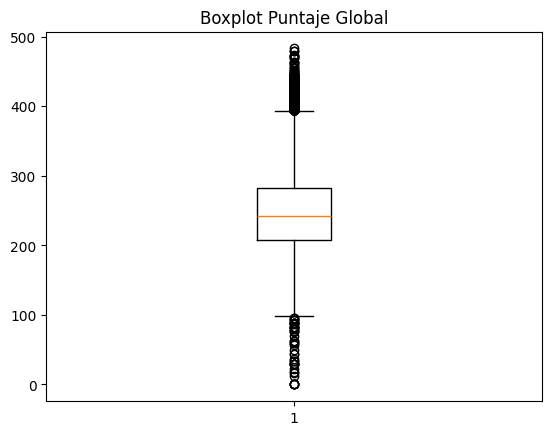

In [172]:
import matplotlib.pyplot as plt

plt.boxplot(df['punt_global'])
plt.title('Boxplot Puntaje Global')
plt.show()

# Descargar subconjunto limpio

Ya con los datos revisados y limpios, podemos descargar el nuevo archivo con los nuevos datos para poder utilizar en el analisis de datos posterior.

In [28]:
df.to_csv("saber11_limpio.csv", index=False)